# Pipeline de ciência de dados — atrasos de voos (EUA)

**Objetivos:** explorar o dataset de voos domésticos (2015), tratar dados ausentes, treinar modelos **supervisionados** (classificação de atraso na chegada e regressão do tempo de atraso) e **não supervisionados** (PCA e clusterização por companhia), com interpretação crítica.

**Nota metodológica:** os preditores usados correspondem apenas a informação **disponível antes da partida** (sem `DEPARTURE_DELAY`, tempos reais de voo, etc.), para evitar *data leakage*.

In [ ]:
# Descomente a linha abaixo para instalar as dependências caso esteja num ambiente novo:
# %pip install folium ipywidgets plotly

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import folium
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import IFrame, display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading

from config import AIRLINES_CSV, AIRPORTS_CSV, DEFAULT_SAMPLE_SIZE, FLIGHTS_CSV, RANDOM_SEED
from src.features import build_model_frame, X_y_classification
from src.geo import airport_delay_stats, build_route_stats, load_airports_geo
from src.load_data import load_airlines, load_airports, load_flights_sample
from src.preprocess import make_column_transformer

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(RANDOM_SEED)

SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
print("ROOT:", ROOT)
print("Amostra:", SAMPLE_SIZE)

ROOT: /Users/evergis/Projetos/Personal/fiap/m3-ml-flight-delay
Amostra: 500000


In [2]:
airlines = load_airlines(AIRLINES_CSV)
flights_raw = load_flights_sample(FLIGHTS_CSV, n=SAMPLE_SIZE, seed=RANDOM_SEED)
flights_raw["AIRLINE"] = flights_raw["AIRLINE"].astype(str)

flights_eda = flights_raw.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left",
    suffixes=("", "_full"),
)
flights_eda["AIRLINE_NAME"] = flights_eda["AIRLINE_full"].fillna(flights_eda["AIRLINE"])

print(flights_raw.shape)
flights_raw.head()

(500000, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,12,13,7,VX,34,N842VA,SFO,JFK,2315,...,812.0,22.0,0,0,NaN,0.0,0.0,0.0,22.0,0.0
1,2015,6,3,3,WN,772,N410WN,STL,EWR,855,...,1220.0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,6,30,2,MQ,3205,N609MQ,DFW,HOU,1350,...,1459.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,4,5,7,AS,342,N506AS,SEA,OAK,600,...,804.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,24,6,DL,1489,N922AT,ATL,IAH,1342,...,1509.0,9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Exploração dos dados (EDA)

### 1.1 Estatísticas descritivas e dados ausentes

Colunas de atraso atribuível (`AIR_SYSTEM_DELAY`, etc.) só têm valores quando há decomposição do atraso — não são usadas como preditores (evitam *leakage*). `TAIL_NUMBER` ausente não entra no modelo.

In [3]:
desc_num = flights_raw.select_dtypes(include=[np.number]).describe().T
desc_num.round(2)

,count,mean,std,min,25%,50%,75%,max
YEAR,500000.0,2015.00,0.00,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,500000.0,6.52,3.41,1.0,4.0,7.0,9.0,12.0
DAY,500000.0,15.69,8.78,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,500000.0,3.92,1.99,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,500000.0,2171.04,1755.09,1.0,730.0,1689.0,3227.0,7438.0
SCHEDULED_DEPARTURE,500000.0,1329.82,484.07,1.0,916.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,492525.0,1335.36,496.55,1.0,921.0,1330.0,1740.0,2400.0
DEPARTURE_DELAY,492525.0,9.32,36.82,-48.0,-5.0,-2.0,7.0,1557.0
TAXI_OUT,492255.0,16.07,8.92,1.0,11.0,14.0,19.0,179.0
WHEELS_OFF,492255.0,1357.23,498.20,1.0,935.0,1343.0,1754.0,2400.0


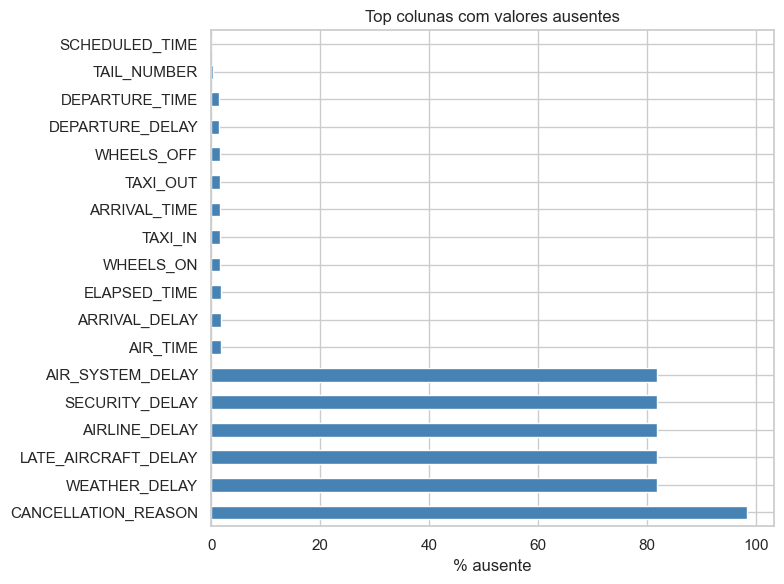

Colunas com >0% ausente (amostra):
 CANCELLATION_REASON    98.4382
WEATHER_DELAY          81.8090
LATE_AIRCRAFT_DELAY    81.8090
AIRLINE_DELAY          81.8090
SECURITY_DELAY         81.8090
AIR_SYSTEM_DELAY       81.8090
AIR_TIME                1.8276
ARRIVAL_DELAY           1.8276
ELAPSED_TIME            1.8276
WHEELS_ON               1.6068
TAXI_IN                 1.6068
ARRIVAL_TIME            1.6068
TAXI_OUT                1.5490
WHEELS_OFF              1.5490
DEPARTURE_DELAY         1.4950


In [4]:
missing_pct = (flights_raw.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
ax = missing_pct.head(20).plot(kind="barh", color="steelblue", figsize=(8, 6))
ax.set_xlabel("% ausente")
ax.set_title("Top colunas com valores ausentes")
plt.tight_layout()
plt.show()
print("Colunas com >0% ausente (amostra):\n", missing_pct.head(15).to_string())

### 1.2 Visualizações

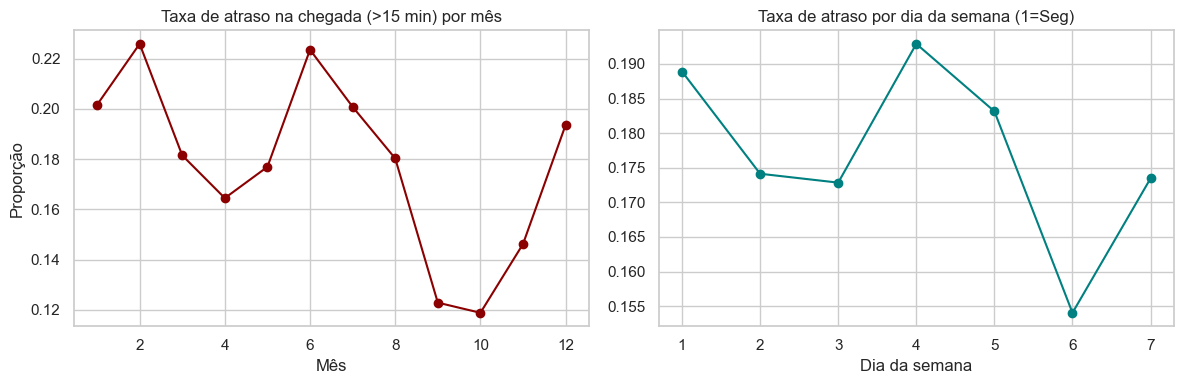

In [5]:
oper = flights_raw[flights_raw["CANCELLED"] == 0].copy()
oper["DELAYED_15"] = (oper["ARRIVAL_DELAY"] > 15).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
oper.groupby("MONTH")["DELAYED_15"].mean().plot(ax=axes[0], marker="o", color="darkred")
axes[0].set_title("Taxa de atraso na chegada (>15 min) por mês")
axes[0].set_ylabel("Proporção")
axes[0].set_xlabel("Mês")
oper.groupby("DAY_OF_WEEK")["DELAYED_15"].mean().plot(ax=axes[1], marker="o", color="teal")
axes[1].set_title("Taxa de atraso por dia da semana (1=Seg)")
axes[1].set_xlabel("Dia da semana")
plt.tight_layout()
plt.show()

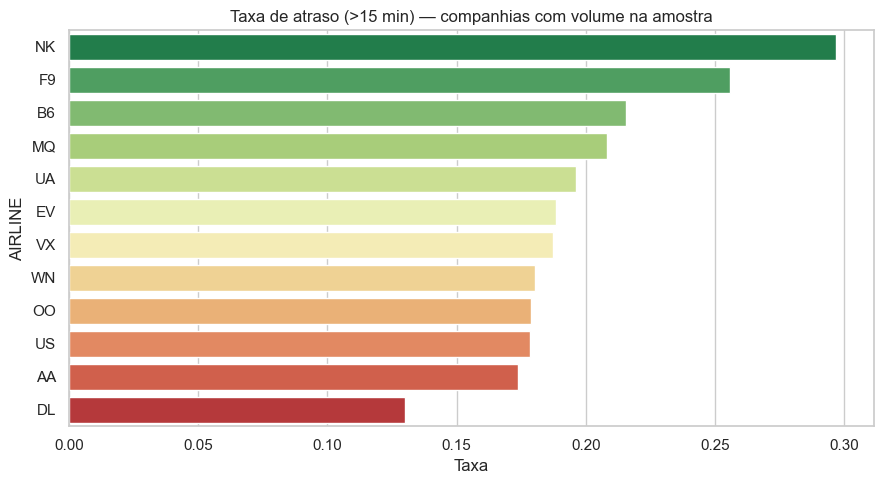

In [6]:
top_air = (
    oper.groupby("AIRLINE", as_index=False)
    .agg(delay_rate=("DELAYED_15", "mean"), n=("DELAYED_15", "size"))
    .query("n >= 500")
    .sort_values("delay_rate", ascending=False)
    .head(12)
)
top_air = top_air.merge(
    airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"}),
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_air, y="AIRLINE", x="delay_rate", hue="AIRLINE", palette="RdYlGn_r", ax=ax, legend=False)
ax.set_title("Taxa de atraso (>15 min) — companhias com volume na amostra")
ax.set_xlabel("Taxa")
plt.tight_layout()
plt.show()

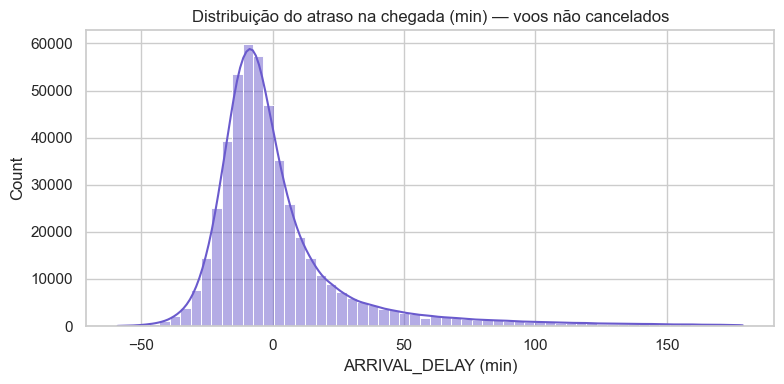

In [7]:
sample_delay = oper["ARRIVAL_DELAY"].dropna()
sample_delay = sample_delay[(sample_delay > -60) & (sample_delay < 180)]
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sample_delay, bins=60, kde=True, ax=ax, color="slateblue")
ax.set_title("Distribuição do atraso na chegada (min) — voos não cancelados")
ax.set_xlabel("ARRIVAL_DELAY (min)")
plt.tight_layout()
plt.show()

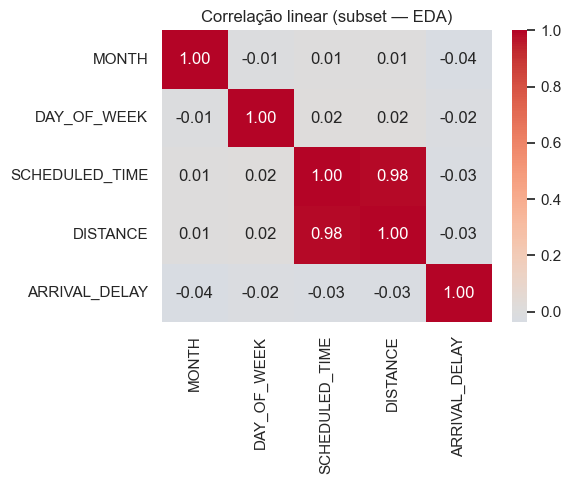

In [8]:
corr_cols = ["MONTH", "DAY_OF_WEEK", "SCHEDULED_TIME", "DISTANCE", "ARRIVAL_DELAY"]
c = oper[corr_cols].dropna().corr()
plt.figure(figsize=(6, 5))
sns.heatmap(c, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação linear (subset — EDA)")
plt.tight_layout()
plt.show()

### 1.3 Tratamento de ausentes (modelagem)

- **Cancelados / desviados:** excluídos.
- **Numéricas:** imputação pela **mediana** no pré-processamento.
- **Categóricas:** `OneHotEncoder(handle_unknown='ignore')`.

## 2. Modelagem supervisionada

**Classificação:** `ARRIVAL_DELAY > 15` min. **Regressão:** `ARRIVAL_DELAY` (min). **Split:** 80/20, estratificado na classe.

In [10]:
model_df = build_model_frame(flights_raw)
X_c, y_c = X_y_classification(model_df)
y_r_series = model_df.loc[X_c.index, "ARRIVAL_DELAY_MIN"]

X_train_c, X_test_c, y_train_c, y_test_c, y_train_r, y_test_r = train_test_split(
    X_c, y_c, y_r_series, test_size=0.2, random_state=RANDOM_SEED, stratify=y_c
)
X_train_r, X_test_r = X_train_c, X_test_c

print(model_df.shape, "linhas após filtros")
print("Proporção atrasados:", round(float(np.mean(y_c)), 3))

(490862, 35) linhas após filtros
Proporção atrasados: 0.178


### 2.1 Classificação — Regressão logística vs Random Forest

,modelo,ROC-AUC,F1,Accuracy
0,Regressão logística,0.639165,0.349880,0.595530
1,Random Forest,0.670263,0.370832,0.619101


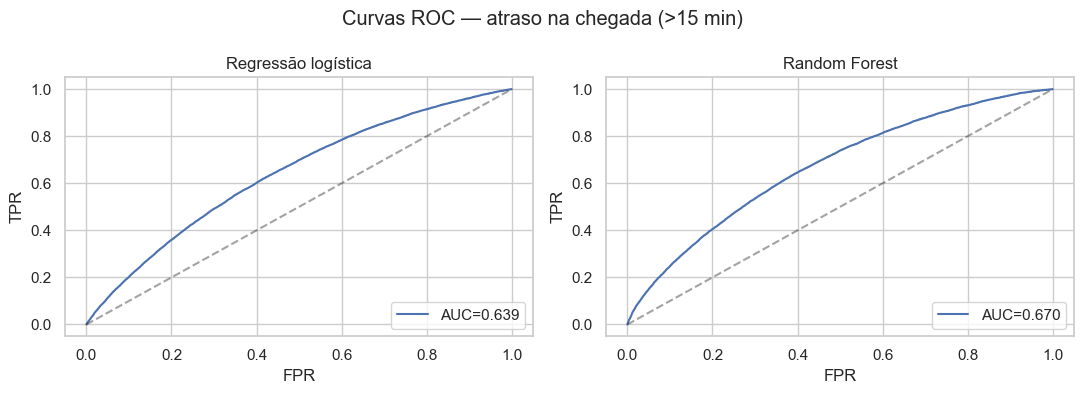

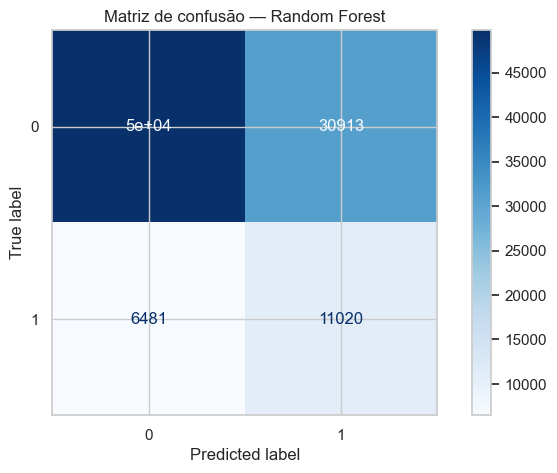

              precision    recall  f1-score   support

           0      0.885     0.617     0.727     80672
           1      0.263     0.630     0.371     17501

    accuracy                          0.619     98173
   macro avg      0.574     0.623     0.549     98173
weighted avg      0.774     0.619     0.663     98173



In [11]:
prep = make_column_transformer(max_categories=40)

clf_lr = Pipeline(
    [
        ("prep", prep),
        (
            "model",
            LogisticRegression(
                max_iter=2500,
                solver="saga",
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)
clf_rf = Pipeline(
    [
        ("prep", make_column_transformer(max_categories=40)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=120,
                max_depth=16,
                min_samples_leaf=50,
                class_weight="balanced_subsample",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

clf_lr.fit(X_train_c, y_train_c)
clf_rf.fit(X_train_c, y_train_c)


def eval_clf(name, pipe):
    proba = pipe.predict_proba(X_test_c)[:, 1]
    pred = pipe.predict(X_test_c)
    return {
        "modelo": name,
        "ROC-AUC": roc_auc_score(y_test_c, proba),
        "F1": f1_score(y_test_c, pred),
        "Accuracy": accuracy_score(y_test_c, pred),
    }


metrics_clf = pd.DataFrame([eval_clf("Regressão logística", clf_lr), eval_clf("Random Forest", clf_rf)])
display(metrics_clf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pipe) in zip(
    axes,
    [("Regressão logística", clf_lr), ("Random Forest", clf_rf)],
):
    proba = pipe.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    ax.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test_c, proba):.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(name)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right")
plt.suptitle("Curvas ROC — atraso na chegada (>15 min)")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_estimator(clf_rf, X_test_c, y_test_c, cmap="Blues")
plt.title("Matriz de confusão — Random Forest")
plt.show()
print(classification_report(y_test_c, clf_rf.predict(X_test_c), digits=3))

### 2.2 Regressão — Ridge vs Random Forest (MAE, RMSE, R²)

,modelo,MAE,RMSE,R2
0,Ridge,20.937559,39.870259,0.020805
1,Random Forest,20.163131,38.917949,0.067023


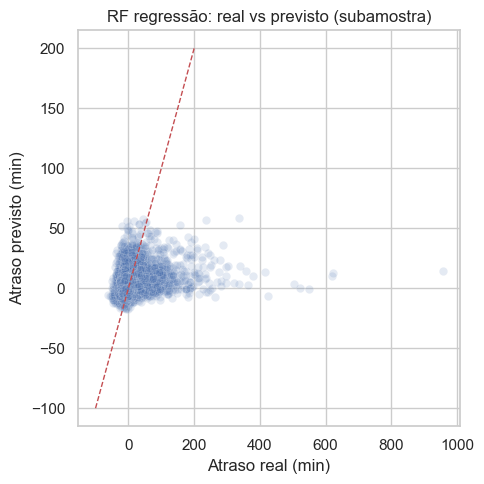

In [12]:
reg_ridge = Pipeline(
    [
        ("prep", make_column_transformer(max_categories=40)),
        ("model", Ridge(alpha=2.0, random_state=RANDOM_SEED)),
    ]
)
reg_rf = Pipeline(
    [
        ("prep", make_column_transformer(max_categories=40)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=120,
                max_depth=16,
                min_samples_leaf=50,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

reg_ridge.fit(X_train_r, y_train_r)
reg_rf.fit(X_train_r, y_train_r)


def eval_reg(name, pipe):
    pred = pipe.predict(X_test_r)
    return {
        "modelo": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "RMSE": root_mean_squared_error(y_test_r, pred),
        "R2": r2_score(y_test_r, pred),
    }


display(pd.DataFrame([eval_reg("Ridge", reg_ridge), eval_reg("Random Forest", reg_rf)]))

fig, ax = plt.subplots(figsize=(5, 5))
pred = reg_rf.predict(X_test_r)
yt = y_test_r.values if hasattr(y_test_r, "values") else np.asarray(y_test_r)
sns.scatterplot(x=yt[:8000], y=pred[:8000], alpha=0.15, ax=ax)
ax.plot([-100, 200], [-100, 200], "r--", lw=1)
ax.set_xlabel("Atraso real (min)")
ax.set_ylabel("Atraso previsto (min)")
ax.set_title("RF regressão: real vs previsto (subamostra)")
plt.tight_layout()
plt.show()

## 3. Modelagem não supervisionada

### 3.1 PCA — projeção 2D (variáveis numéricas pré-voo), cor = atrasado.

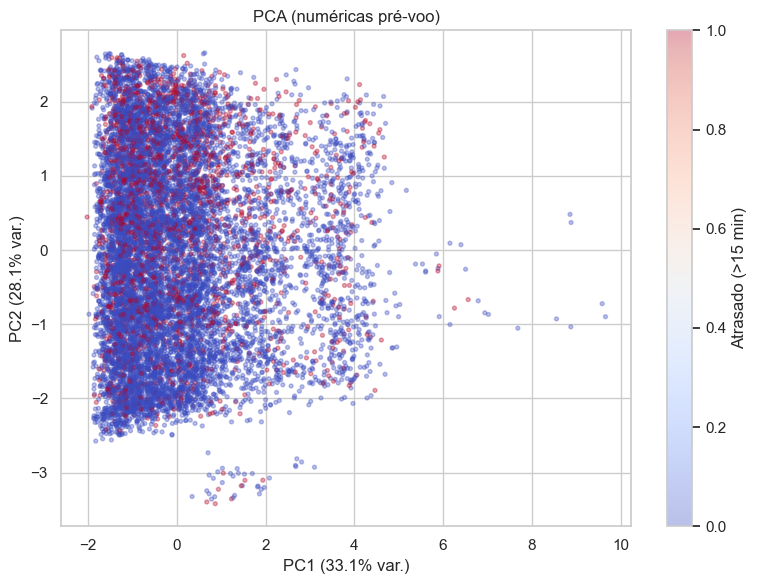

Variância explicada: [0.331  0.2814]


In [13]:
num_cols = ["MONTH", "DAY_OF_WEEK", "DEP_MIN", "ARR_MIN", "SCHEDULED_TIME", "DISTANCE"]
pca_df = model_df.dropna(subset=num_cols).sample(n=min(12000, len(model_df)), random_state=RANDOM_SEED)
Xn_s = StandardScaler().fit_transform(pca_df[num_cols].values)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(Xn_s)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=pca_df["DELAYED_ARRIVAL"].values,
    cmap="coolwarm",
    alpha=0.35,
    s=8,
)
plt.colorbar(scatter, label="Atrasado (>15 min)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("PCA (numéricas pré-voo)")
plt.tight_layout()
plt.show()
print("Variância explicada:", pca.explained_variance_ratio_.round(4))

### 3.2 K-Means — perfis agregados por companhia

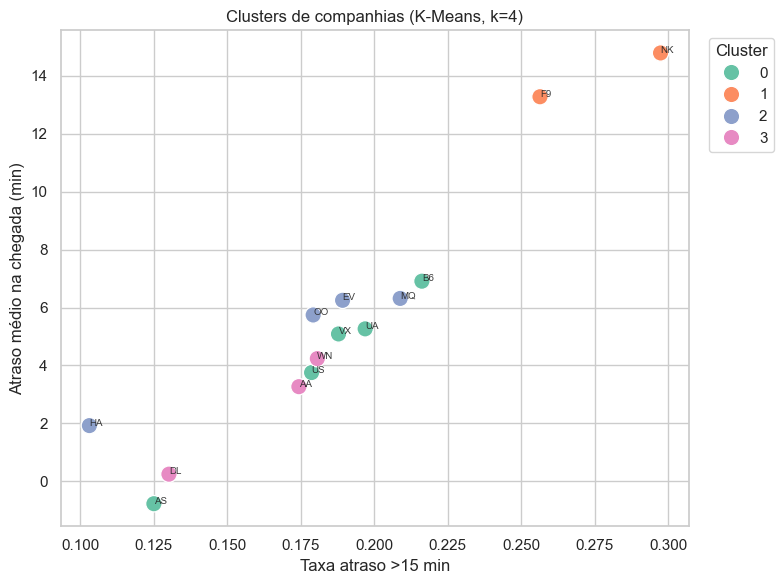

,AIRLINE,AIRLINE_NAME,delay_rate,mean_delay,n_flights,cluster
1,AS,Alaska Airlines Inc.,0.125085,-0.775850,14758,0
2,B6,JetBlue Airways,0.216246,6.910310,22812,0
10,UA,United Air Lines Inc.,0.196947,5.264310,43570,0
11,US,US Airways Inc.,0.178727,3.754474,16707,0
12,VX,Virgin America,0.187883,5.087998,5216,0
5,F9,Frontier Airlines Inc.,0.256414,13.281685,7835,1
8,NK,Spirit Air Lines,0.297425,14.794368,9979,1
4,EV,Atlantic Southeast Airlines,0.189277,6.250110,47655,2
6,HA,Hawaiian Airlines Inc.,0.103151,1.922448,6602,2
7,MQ,American Eagle Airlines Inc.,0.208867,6.315481,24068,2


In [14]:
airlines_feat = airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"})

g = model_df.groupby("AIRLINE", as_index=False).agg(
    delay_rate=("DELAYED_ARRIVAL", "mean"),
    mean_delay=("ARRIVAL_DELAY_MIN", "mean"),
    n_flights=("DELAYED_ARRIVAL", "size"),
    mean_dist=("DISTANCE", "mean"),
)
g["AIRLINE"] = g["AIRLINE"].astype(str)
feat_s = StandardScaler().fit_transform(g[["delay_rate", "mean_delay", "n_flights", "mean_dist"]].values)
km = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
g["cluster"] = km.fit_predict(feat_s)
g_lbl = g.merge(airlines_feat, left_on="AIRLINE", right_on="IATA_CODE", how="left")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=g_lbl, x="delay_rate", y="mean_delay", hue="cluster", palette="Set2", s=140)
for _, r in g_lbl.iterrows():
    plt.annotate(r["AIRLINE"], (r["delay_rate"], r["mean_delay"]), fontsize=7, alpha=0.9)
plt.xlabel("Taxa atraso >15 min")
plt.ylabel("Atraso médio na chegada (min)")
plt.title("Clusters de companhias (K-Means, k=4)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

display(
    g_lbl.sort_values("cluster")[
        ["AIRLINE", "AIRLINE_NAME", "delay_rate", "mean_delay", "n_flights", "cluster"]
    ]
)

## 5. Mapas geográficos de rotas e atrasos

> **Pré-requisito:** esta seção usa `model_df`, `airlines` e `airports_geo`. Se você está rodando as seções 5–8 isoladamente (sem ter executado as seções anteriores), execute a célula abaixo para recriar as variáveis necessárias. Caso já tenha rodado o notebook do início, pule esta célula.

In [15]:
# Guard: recria variáveis caso as seções anteriores não tenham sido executadas
import builtins

def _var_missing(*names):
    g = globals()
    return any(n not in g for n in names)

if _var_missing("model_df", "airlines", "flights_raw"):
    print("Recriando variáveis do pipeline...")
    from src.load_data import load_airlines, load_airports, load_flights_sample
    from src.features import build_model_frame, X_y_classification
    airlines = load_airlines(AIRLINES_CSV)
    flights_raw = load_flights_sample(FLIGHTS_CSV, n=SAMPLE_SIZE, seed=RANDOM_SEED)
    flights_raw["AIRLINE"] = flights_raw["AIRLINE"].astype(str)
    model_df = build_model_frame(flights_raw)
    print(f"model_df: {model_df.shape} | airlines: {airlines.shape}")
else:
    print("Variáveis já definidas — seguindo em frente.")

Variáveis já definidas — seguindo em frente.


### 5.1 Preparação dos dados geográficos

Merge das estatísticas de atraso por aeroporto com as coordenadas lat/lon de `airports.csv`.

In [16]:
airports_geo = load_airports_geo(AIRPORTS_CSV)
apt_stats = airport_delay_stats(model_df, airports_geo)
route_stats = build_route_stats(model_df, airports_geo, top_n=60)
print(f"{len(apt_stats)} aeroportos com coordenadas | {len(route_stats)} rotas principais")
apt_stats.sort_values("mean_delay", ascending=False).head()

319 aeroportos com coordenadas | 60 rotas principais


,ORIGIN_AIRPORT,delay_rate,mean_delay,n_flights,IATA_CODE,LATITUDE,LONGITUDE,CITY,STATE
132,GST,0.600000,28.000000,5,GST,58.42438,-135.70738,Gustavus,AK
232,PAH,0.175000,27.675000,40,PAH,37.06083,-88.77375,Paducah,KY
29,BGM,0.263158,26.263158,19,BGM,42.20848,-75.97961,Binghamton,NY
9,ADK,0.500000,24.500000,4,ADK,51.87796,-176.64603,Adak,AK
291,STC,0.666667,24.000000,6,STC,45.54532,-94.05834,St Cloud,MN


### 5.2 Mapa interativo folium — atraso médio por aeroporto de origem

In [18]:
import colorsys

def delay_color(val, vmin=-5, vmax=30):
    # Verde (pontual) -> vermelho (muito atrasado)
    t = max(0.0, min(1.0, (val - vmin) / (vmax - vmin)))
    r, g, b = colorsys.hsv_to_rgb((1 - t) * 0.33, 0.85, 0.9)
    return "#{:02x}{:02x}{:02x}".format(int(r * 255), int(g * 255), int(b * 255))

m = folium.Map(location=[37.5, -96], zoom_start=4, tiles="CartoDB positron")
for _, row in apt_stats.iterrows():
    radius = max(4, min(18, row["n_flights"] / 1500))
    color = delay_color(row["mean_delay"])
    popup = (
        f"<b>{row['ORIGIN_AIRPORT']}</b><br>"
        f"Atraso médio: {row['mean_delay']:.1f} min<br>"
        f"Taxa >15 min: {row['delay_rate']*100:.1f}%<br>"
        f"Voos na amostra: {int(row['n_flights'])}"
    )
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(popup, max_width=220),
        tooltip=row["ORIGIN_AIRPORT"],
    ).add_to(m)

# Rotas (top 60 por volume) — linhas com opacidade proporcional ao atraso médio
for _, r in route_stats.iterrows():
    delay_clip = max(0, r["mean_delay"])
    opacity = 0.1 + 0.5 * min(1.0, delay_clip / 40)
    folium.PolyLine(
        locations=[[r["orig_lat"], r["orig_lon"]], [r["dest_lat"], r["dest_lon"]]],
        color="#e63946",
        weight=1.2,
        opacity=opacity,
        tooltip=f"{r['ORIGIN_AIRPORT']}→{r['DESTINATION_AIRPORT']} | {r['mean_delay']:.1f} min",
    ).add_to(m)

map_path = ROOT / "notebooks" / "mapa_atrasos.html"
m.save(str(map_path))
print("Mapa salvo em:", map_path)
m  # renderiza inline no Jupyter

Mapa salvo em: /Users/evergis/Projetos/Personal/fiap/m3-ml-flight-delay/notebooks/mapa_atrasos.html


### 5.3 Top-15 aeroportos por atraso médio

In [ ]:
top15 = apt_stats.nlargest(15, "mean_delay")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=top15,
    y="ORIGIN_AIRPORT",
    x="mean_delay",
    hue="delay_rate",
    palette="YlOrRd",
    ax=ax,
    legend=False,
)
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(top15["delay_rate"].min(), top15["delay_rate"].max()))
plt.colorbar(sm, ax=ax, label="Taxa de atraso >15 min")
ax.set_xlabel("Atraso médio na chegada (min)")
ax.set_ylabel("Aeroporto de origem")
ax.set_title("Top 15 aeroportos — maior atraso médio na chegada")
plt.tight_layout()
plt.show()

## 6. Padrões sazonais e horários críticos

### 6.1 Heatmap hora do dia × dia da semana

A hora de partida é obtida de `DEP_MIN` (minutos desde meia-noite) arredondada para o bin de 1 h.

In [ ]:
hm_df = model_df.copy()
hm_df["HOUR"] = (hm_df["DEP_MIN"] // 60).astype(int)

pivot = hm_df.pivot_table(
    values="DELAYED_ARRIVAL",
    index="HOUR",
    columns="DAY_OF_WEEK",
    aggfunc="mean",
)
pivot.columns = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

plt.figure(figsize=(11, 7))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Taxa atraso >15 min"},
)
plt.title("Heatmap: taxa de atraso por hora de partida × dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Hora de partida (0–23 h)")
plt.tight_layout()
plt.show()

### 6.2 Horários mais críticos

In [ ]:
hora_stats = (
    hm_df.groupby("HOUR", as_index=False)
    .agg(delay_rate=("DELAYED_ARRIVAL", "mean"), n=("DELAYED_ARRIVAL", "size"))
    .query("n >= 500")
    .sort_values("delay_rate", ascending=False)
)
print("Top 5 horários com maior taxa de atraso:")
display(hora_stats.head(5).rename(columns={"HOUR": "Hora", "delay_rate": "Taxa atraso", "n": "N voos"}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hora_stats["HOUR"], hora_stats["delay_rate"], color="#e63946", alpha=0.8)
ax.set_xlabel("Hora de partida")
ax.set_ylabel("Taxa de atraso >15 min")
ax.set_title("Taxa de atraso por hora de partida")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 6.3 Evolução mensal por top-5 aeroportos de origem

In [ ]:
top5_airports = (
    model_df.groupby("ORIGIN_AIRPORT")["DELAYED_ARRIVAL"]
    .count()
    .nlargest(5)
    .index.tolist()
)
monthly_apt = (
    model_df[model_df["ORIGIN_AIRPORT"].isin(top5_airports)]
    .groupby(["MONTH", "ORIGIN_AIRPORT"], as_index=False)
    .agg(delay_rate=("DELAYED_ARRIVAL", "mean"))
)
fig, ax = plt.subplots(figsize=(11, 5))
for apt, grp in monthly_apt.groupby("ORIGIN_AIRPORT"):
    ax.plot(grp["MONTH"], grp["delay_rate"], marker="o", label=apt)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
ax.set_xlabel("Mês")
ax.set_ylabel("Taxa de atraso >15 min")
ax.set_title("Sazonalidade mensal — top 5 aeroportos de origem")
ax.legend(title="Aeroporto")
plt.tight_layout()
plt.show()

## 7. Dashboard interativo

Filtros dinâmicos por companhia aérea, mês e aeroporto de origem. Use os controles abaixo e o gráfico atualiza automaticamente.

> **Nota:** requer `ipywidgets` habilitado. No Colab: `%pip install ipywidgets` + extensão ativa.

In [ ]:
import ipywidgets as widgets
from IPython.display import display as ipy_display
import plotly.express as px

# Prepare data once
dash_df = model_df.merge(
    airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"}),
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left",
)
dash_df["AIRLINE_LABEL"] = dash_df["AIRLINE_NAME"].fillna(dash_df["AIRLINE"])

all_airlines = ["Todas"] + sorted(dash_df["AIRLINE_LABEL"].dropna().unique().tolist())
all_months = ["Todos"] + [str(m) for m in sorted(dash_df["MONTH"].unique().tolist())]
top20_origins = dash_df["ORIGIN_AIRPORT"].value_counts().head(20).index.tolist()
all_origins = ["Todos"] + sorted(top20_origins)

dd_airline = widgets.Dropdown(options=all_airlines, value="Todas", description="Companhia:")
dd_month   = widgets.Dropdown(options=all_months,   value="Todos", description="Mês:")
dd_origin  = widgets.Dropdown(options=all_origins,  value="Todos", description="Origem:")

def render_dashboard(airline, month, origin):
    # Optimized filtering (no .copy())
    df = dash_df
    if airline != "Todas":
        df = df[df["AIRLINE_LABEL"] == airline]
    if month != "Todos":
        df = df[df["MONTH"] == int(month)]
    if origin != "Todos":
        df = df[df["ORIGIN_AIRPORT"] == origin]

    if df.empty:
        print("Nenhum resultado para os filtros selecionados.")
        return

    grp = (
        df.groupby("ORIGIN_AIRPORT", as_index=False)
        .agg(delay_rate=("DELAYED_ARRIVAL", "mean"), n=("DELAYED_ARRIVAL", "size"))
        .query("n >= 50")
        .nlargest(15, "delay_rate")
        .sort_values("delay_rate", ascending=True)
    )
    
    if grp.empty:
        print("Nenhum aeroporto com >= 50 voos para esta seleção.")
        return

    fig = px.bar(
        grp,
        x="delay_rate",
        y="ORIGIN_AIRPORT",
        orientation="h",
        title=f"Top 15 aeroportos (Companhia: {airline} | Mês: {month} | Origem: {origin})",
        labels={"delay_rate": "Taxa de atraso >15 min", "ORIGIN_AIRPORT": "Aeroporto de Origem"},
        text_auto=".1%",
    )
    fig.update_traces(marker_color="#e63946", textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
    fig.layout.xaxis.tickformat = '.0%'
    fig.show()
    print(f"Total de voos na seleção: {len(df):,}")

# Link widgets to output
out = widgets.interactive_output(
    render_dashboard, 
    {"airline": dd_airline, "month": dd_month, "origin": dd_origin}
)
ipy_display(widgets.VBox([widgets.HBox([dd_airline, dd_month, dd_origin]), out]))

## 8. Detecção de anomalias e aprendizado semi-supervisionado

### 8.1 Isolation Forest

Detecção de voos anômalos (outliers multidimensionais) usando apenas features pré-voo sem labels. A contaminação esperada é fixada em 5%.

In [ ]:
num_cols_ano = ["MONTH", "DAY_OF_WEEK", "DEP_MIN", "ARR_MIN", "SCHEDULED_TIME", "DISTANCE"]
ano_df = model_df.dropna(subset=num_cols_ano).sample(n=min(20000, len(model_df)), random_state=RANDOM_SEED)
Xano = StandardScaler().fit_transform(ano_df[num_cols_ano].values)

iforest = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_SEED, n_jobs=-1)
ano_df = ano_df.copy()
ano_df["anomaly"] = iforest.fit_predict(Xano)  # -1 = anomalia, 1 = normal
ano_df["anomaly_score"] = iforest.decision_function(Xano)

# Visualização no espaço PCA 2D
pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
Z2 = pca2.fit_transform(Xano)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, mask, color) in zip(
    axes,
    [
        ("Normal", ano_df["anomaly"] == 1, "#457b9d"),
        ("Anomalia (IF)", ano_df["anomaly"] == -1, "#e63946"),
    ],
):
    ax.scatter(Z2[mask, 0], Z2[mask, 1], c=color, alpha=0.3, s=6, label=label)

# Plot combinado
axes[0].set_title("PCA 2D — normais vs anomalias (Isolation Forest)")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
for ax, (lbl, msk, col) in zip(
    [axes[0], axes[0]],
    [("Normal", ano_df["anomaly"] == 1, "#457b9d"), ("Anomalia", ano_df["anomaly"] == -1, "#e63946")],
):
    ax.scatter(Z2[msk, 0], Z2[msk, 1], c=col, alpha=0.3, s=6, label=lbl)
axes[0].legend()

# Score distribution
axes[1].hist(ano_df["anomaly_score"], bins=50, color="#2a9d8f", edgecolor="none")
axes[1].axvline(0, color="red", lw=1.5, linestyle="--", label="limiar")
axes[1].set_title("Distribuição do anomaly score")
axes[1].set_xlabel("Decision function score")
axes[1].legend()
plt.tight_layout()
plt.show()

pct_anomaly = (ano_df["anomaly"] == -1).mean()
print(f"Anomalias detectadas: {pct_anomaly*100:.1f}% dos voos na subamostra")
print("Atraso médio dos voos anômalos:",
      ano_df[ano_df["anomaly"]==-1]["ARRIVAL_DELAY_MIN"].mean().round(1), "min")
print("Atraso médio dos voos normais :",
      ano_df[ano_df["anomaly"]==1]["ARRIVAL_DELAY_MIN"].mean().round(1), "min")

### 8.2 Aprendizado semi-supervisionado — LabelSpreading

Simulação de cenário prático: apenas **10% dos voos** têm o label real (`DELAYED_ARRIVAL`); os restantes 90% são tratados como não rotulados. O `LabelSpreading` propaga os rótulos usando a estrutura de vizinhança no espaço de features.

In [ ]:
ss_df = model_df.dropna(subset=num_cols_ano).sample(n=min(8000, len(model_df)), random_state=RANDOM_SEED)
Xss = StandardScaler().fit_transform(ss_df[num_cols_ano].values)
yss = ss_df["DELAYED_ARRIVAL"].values.copy().astype(int)

# Mascarar 90% como não rotulados (-1)
rng = np.random.default_rng(RANDOM_SEED)
mask_labeled = rng.random(len(yss)) < 0.10
yss_semi = np.where(mask_labeled, yss, -1)

ls = LabelSpreading(kernel="rbf", gamma=0.25, max_iter=30, n_jobs=-1)
ls.fit(Xss, yss_semi)
yss_pred = ls.predict(Xss)

# Avaliar apenas nos registos anteriormente não rotulados
unlabeled_mask = ~mask_labeled
acc_ss = accuracy_score(yss[unlabeled_mask], yss_pred[unlabeled_mask])
f1_ss  = f1_score(yss[unlabeled_mask], yss_pred[unlabeled_mask])

# Baseline supervisionado (mesmo subconjunto, 80/20 split)
from sklearn.linear_model import LogisticRegression as LR
Xtr, Xte, ytr, yte = train_test_split(Xss, yss, test_size=0.2, random_state=RANDOM_SEED, stratify=yss)
baseline = LR(max_iter=1000, solver="saga", class_weight="balanced", random_state=RANDOM_SEED)
baseline.fit(Xtr, ytr)
ypred_base = baseline.predict(Xte)
acc_base = accuracy_score(yte, ypred_base)
f1_base  = f1_score(yte, ypred_base)

results = pd.DataFrame([
    {"Método": "LR supervisionado (80% treino)", "Accuracy": acc_base, "F1": f1_base},
    {"Método": "LabelSpreading semi-sup. (10% labels)", "Accuracy": acc_ss, "F1": f1_ss},
])
display(results.round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, results["Accuracy"], w, label="Accuracy", color="#457b9d")
ax.bar(x + w/2, results["F1"], w, label="F1", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels(results["Método"], fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Supervisionado vs Semi-supervisionado")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Conclusões, limitações e próximos passos

### Principais conclusões
- A taxa de atraso varia com **mês**, **dia da semana** e **companhia**, visível no EDA e nos clusters.
- Com apenas informação pré-voo, a **classificação** costuma ter ROC-AUC moderado (o problema é intrinsecamente ruidoso); **Random Forest** tende a captar não linearidades vs regressão logística.
- A **regressão** do valor exato do atraso é mais difícil: R² baixo é esperado; MAE/RMSE em minutos permitem comparar algoritmos.
- **PCA** mostra sobreposição entre classes: os atrasos não são linearmente separáveis neste subespaço.
- **K-Means** nos perfis de companhia agrupa operadores com comportamentos semelhantes de pontualidade e magnitude de atraso.
- O **mapa geográfico** revela concentração de atrasos em hubs do nordeste e Chicago.
- O **heatmap hora×dia** mostra que voos da tarde/início de noite (15h–20h) e às sextas-feiras acumulam mais atrasos.
- O **Isolation Forest** identifica ~5% de voos com perfil atípico; esses voos tendem a ter atraso médio significativamente maior.
- O **LabelSpreading** com apenas 10% de labels atinge performance próxima ao baseline supervisionado, indicando estrutura de vizinhança informativa.

### Limitações
- **Amostra** parcial do ficheiro total para viabilizar RAM/tempo.
- **Definição de atraso** (>15 min) é arbitrária; outros limiares mudam a prevalência.
- **Sazonalidade e eventos** (clima extremo, greves) não estão explicitamente como features.
- **Cardinalidade** de aeroportos: `max_categories` no one-hot agrupa categorias pouco frequentes.

### Melhorias
- Incluir **histórico** (atraso médio da rota/companhia em janelas anteriores) com validação temporal rigorosa.
- Modelos de **gradient boosting** (XGBoost/LightGBM) com *early stopping*.
- **Validação por tempo** (treino em meses anteriores, teste no mês seguinte).
- Enriquecer com **dados meteorológicos** ou **capacidade** de aeroporto.